In [13]:
from utils import * 
import subprocess
import json
import itertools
import requests

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# No genes in this cluster have any InterProScan annotations. 

In [15]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/server/'

In [16]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['gene_id'] = genes_df.index
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 6].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_6.faa')
# subprocess.run('muscle -align ../data/genes/cluster_6.faa -output ../data/genes/cluster_6.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}\t{row.seq}')

print('\nMinimum cluster_6 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_6 gene length:', genes_df.seq.apply(len).max())

msa = MSAFile.from_file('../data/genes/cluster_6.afa')

orfm.bz_0.1_169	MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLNFTDSQDITGELVHNKGLPIVIFERPFSGAILFSESCVYRNHTKDGELTMDLVKDYPFGIDHKSDLFKYNGIEYTNNQYEIRITDKSLEQYYSKKYKFYIPIMLNRTPIPIIRLDKADRILNKVDEKNVKRLSNITQTFLREFTRLKLLERTGTKKDGVGWILFFGWMAGLATYAIVSLFVK
orfm.bz_1.1_143	MGFFDGIEKIKLPNIGNLIHEGKDIKTQIKKIDINGINVRYWNKDCTYYTPTKGIIYRYTNVSLVIMKIPEKLGVIIIDNTIHFNKFTKEEELDVIEGFGFTVDLSHQPILEKELSELKTIIAKKEIKDIKNYTIPAMINKIPVPIVRVNLNQNLGTLPDYVAISQKFLYEISMVKILQKVNKQKHEGLFIVLVLGIFIGIFLGSAMMGYILR
orfm.bz_2.1_38	MSFSSTLKSIKFPDTKEALETPSRIREETDKTNLNHITVMYFTRKFAKCIRVKGVISHETSVPIIYFNKPENLGIIDFDNTSFYDETLKELCIIVSEDYLFSLDMNSEYKLIHNLKIQYYNDTIRYKAKSKDIKKIGNRGKLLFEKTNCAYMLPIFLNNIPREVIKINIENNVLDNTIQDSDVEEKNTQIEEKILNDYDKKIEVTQYIVRQFATVKMLSNLQKPNNSIIIACALMFIPLGLIMGIFITLFFFR
orfm.bz_3.1_56	MGFFNKLSKADLPESQDIIEIPKKLKEQSDNSKLNDITVRFFNQDFSKVIESIGKISHKTSIPIIYFDKPEKLAVIMFDDTSYIDVTRNNKLCIDVCESYPYAIDKNISIFRDDKIKYFNEKYKKSYKELEEIYKKSERKLYIPILLNNIPIPIIEIEKNYKTSMINGEWITHKKTITMNLIRQLSDIKLLERVGKKDNSALMFCALLFLLIGILTGFIMAIWVIG
orfm.bz_4.1_159

In [39]:
# It seems as though ColabFold was able to generate reasonable MSAs for these, but for AlphaFold3, there will be a considerable speed-up if using the MSAs from the analysis-1-cluster.ipynb
# notebook. My worry is that the structure quality could be reduced if fewer sequences are included in the MSA, but I will evaluate this using the AlphaFold server. 

ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_6-multimer' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.

# Generate the input files for the local version of AlphaFold3 on biotite. For now, I will just use the automatically-generated MSAs, 
# which seem to produce higher-confidence structures than the custom MSA with 10 sequences. 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

msas = get_msas_unpaired(genes_df.index.tolist())

for row in genes_df.itertuples():

    for n in range(5, 10):

        input = AlphaFoldInputFile(f'{row.genome_id}_cluster_6_{n}mer', version=2, num_seeds=10)
        input.add_seq(row.seq, n=n, paired_msa='', unpaired_msa=msas[row.Index])
        input.write(os.path.join(ALPHAFOLD_INPUT_DIR, input.name + '.json'))



# print('sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"')
cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_6-multimer/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


In [18]:
# # Generate AlphaFold server input for some exploratory analysis of possible oligomerization states. 

# genome_id = 'bz_1'

# path = os.path.join(ALPHAFOLD_INPUT_DIR, 'cluster_6.json')
# msas = get_msas_unpaired(genes_df.index)

# inputs = list()
# for genome_id, df in genes_df[genes_df.genome_id == 'bz_0'].groupby('genome_id'):
#     entry = df.iloc[0]
#     for count in list(range(1, 8)) + [10, 12]:
#         name = f'{genome_id}_cluster_6_{count}mer'

#         input = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=2)
#         input.add_seq(entry.seq, paired_msa='', unpaired_msa=msas[entry.gene_id], n=count)

#         print(f'Generated input for {input.name}.')
#         inputs.append(input)


# with open(path, 'w') as f:
#     json.dump([input.get_info() for input in inputs], f)

# # # find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +
# # output_dirs = [
# #     os.path.join('../data/genes/alphafold/server/', input.name.replace('-', '_')) for input in inputs]
# # outputs = [AlphaFoldServerOutput(path) for path in output_dirs if os.path.exists(path)]
# # print(f'\nLoaded {len(outputs)} AlphaFoldServer outputs.')

# # # Based on the ipTMs of the best models, it seems as though the ATP-bound structures for bz_0 are more confident than the ADP-bound structures. 
# # for output in outputs:
# #     print(output.name, 'ipTM:', output.get_iptms(best_model=True))


In [19]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
# There is one transmembrane helix in each protein, and they are at the C-terminus. This suggests a membrane anchor. 
# prob_n_inside in TMHMM is the predicted probability that the N-terminus of the protein is on the cytoplasmic/inside side of the membrane.
# So it seems as though the N-terminus is in the cytoplasm. 


tmhmm_df = tmhmm_file.to_df()
tmhmm_df = tmhmm_df[tmhmm_df.gene_id.isin(genes_df.index)].copy()
tmhmm_df = tmhmm_df[tmhmm_df.location == 'TMhelix'].copy()
genes_df['tmh_start'] = genes_df.index.map(tmhmm_df.set_index('gene_id').start)
genes_df['tmh_stop'] = genes_df.index.map(tmhmm_df.set_index('gene_id').end)

for row in genes_df.itertuples():
    seq = row.seq[row.tmh_start - 10:row.tmh_start]
    rk_count = seq.count('R') + seq.count('K')
    print(f'Number of positive residues before TMH in {row.genome_id}:', rk_count, f'\t{seq}')

Number of positive residues before TMH in bz_0: 3 	ERTGTKKDGV
Number of positive residues before TMH in bz_1: 3 	KVNKQKHEGL
Number of positive residues before TMH in bz_2: 1 	LQKPNNSIII
Number of positive residues before TMH in bz_3: 2 	VGKKDNSALM
Number of positive residues before TMH in bz_4: 2 	EKTGTKQDNI
Number of positive residues before TMH in bz_5: 3 	RVGKKDNSAL
Number of positive residues before TMH in bz_7: 1 	MNEKDNSGHV
Number of positive residues before TMH in bz_8: 3 	ERVGKKDNSA
Number of positive residues before TMH in bz_9: 1 	DINEKGNDGF
Number of positive residues before TMH in bz_10: 2 	RTGKGDNTVL


In [20]:
# TODO
# (1) Look at the linker between the TMH and globular domain (flexible or rigid?)
# (2) Look for positively-charged residue enrichment to the left of the TMH (see Heijne 1986). 
# (3) Look into archaeal translocation, or how likely it is that it is external without a signal peptide. 


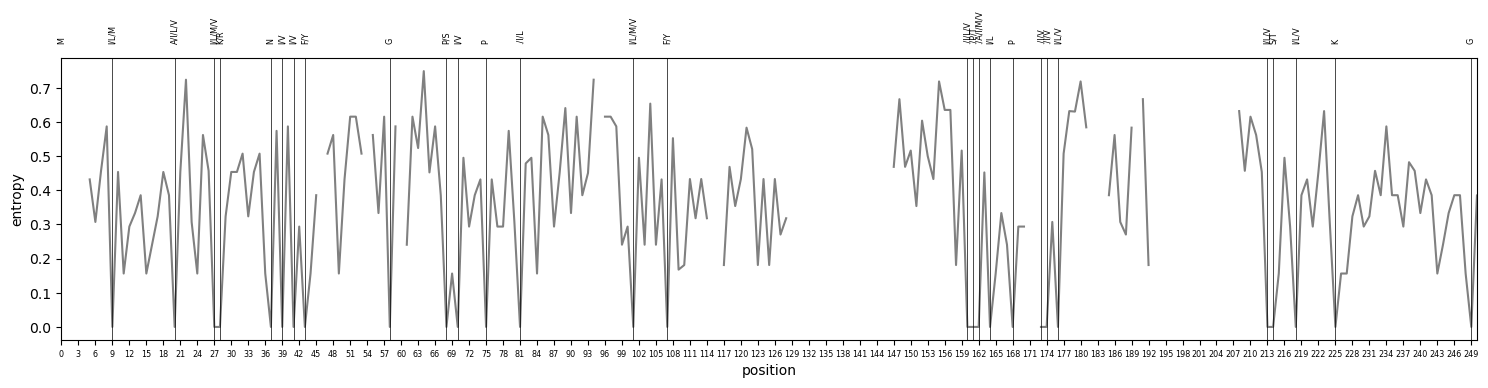

In [21]:
def plot_entropy(msa:MSAFile, max_entropy=0.1, x_min=20, x_max=70, ax:plt.Axes=None):

    entropy = msa.get_entropy(alphabet=REDUCED_ALPHABET)

    ax.plot(np.arange(len(entropy)), entropy, color='gray')

    conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
    # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
    conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

    for idx, aas in zip(conserved_idxs, conserved_aas):
        if (idx > x_max) or (idx < x_min):
            continue
        ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
        ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 3)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

fig, ax = plt.subplots(figsize=(15, 4), nrows=1)
plot_entropy(msa, ax=ax, x_max=250, x_min=0)


fig.tight_layout()
plt.show()


In [22]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['long_alignment'] = foldseek_search_df.alignment_length > 300 # Looked at some of these alignments, and all were pretty clearly garbage.
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')
filters['match_to_c_terminal_helix'] = foldseek_search_df.query_start > 100 # These are all kinda meaningless. 

foldseek_search_df = apply_filters(filters, foldseek_search_df)


# Q684C2 is a good hit, which is an uncharacterized Sulfolobus virus STSV1 protein (double-stranded DNA archaeal virus). 
# A7K8E0 is a False positive. 
# P-ring formation protein FlgA hit is potentially very interesting

apply_filters: 11162 entries removed by low_tm_score.
apply_filters: 142 entries removed by short_alignment.
apply_filters: 4072 entries removed by long_alignment.
apply_filters: 74 entries removed by synthetic.
apply_filters: 351 entries removed by match_to_c_terminal_helix.


In [38]:
categories = dict()
categories['ubiquitin transferase'] = foldseek_search_df.target_header.str.contains('ubiquitin', case=False)
categories['NADH-quinone oxidoreductase'] = foldseek_search_df.target_header.str.contains('quinone', case=False) # These are false positives.
categories['RimM'] = foldseek_search_df.target_header.str.contains('ribosome maturation|ribosomal RNA-processing', case=False) # These are false positives.
categories['RNA-binding'] = foldseek_search_df.target_header.str.contains('RNA-binding', case=False) # These are false positives.
categories['srb-7'] = foldseek_search_df.target_header.str.contains('Mediator of RNA polymerase II transcription subunit 21', case=False)
categories['phosphoribosyl-AMP cyclohydrolase'] = foldseek_search_df.target_header.str.contains('Phosphoribosyl-AMP cyclohydrolase', case=False)
categories['large ribosomal subunit bL25'] = foldseek_search_df.target_header.str.contains('Large ribosomal subunit protein bL25', case=False)
categories['large ribosomal subunit bL31B'] = foldseek_search_df.target_header.str.contains('Large ribosomal subunit protein bL31B', case=False)
categories['small ribosomal subunit eS6'] = foldseek_search_df.target_header.str.contains('Small ribosomal subunit protein eS6', case=False)
categories['DUF402 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF402', case=False) # https://www.ebi.ac.uk/interpro/entry/pfam/PF04167/
categories['FlgA'] = foldseek_search_df.target_header.str.contains('FlgA', case=False)
categories['transcriptional regulator'] = foldseek_search_df.target_header.str.contains('transcriptional regulator', case=False)
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)

categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')

foldseek_search_df[foldseek_search_df.category == 'none'].drop_duplicates('target_id').iloc[-100:][['alignment_length', 'percent_identity', 'query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header', 'alignment_tm_score']].iloc[:50]
# foldseek_search_df.sort_values('alignment_tm_score').drop_duplicates('target_id').iloc[-100:][['percent_identity', 'query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header', 'alignment_tm_score']].iloc[:50]

,alignment_length,percent_identity,query_length,target_length,query_start,query_end,target_end,target_header,alignment_tm_score
37021,85,8.2,228,364,29,110,364,AF-A0A835W5V5-F1-model_v6 BPL/LPL catalytic do...,0.5677
37063,158,4.4,213,132,30,176,99,AF-A0A938IVW4-F1-model_v6 PRC-barrel domain co...,0.5952
37076,128,0.0,213,90,31,143,86,AF-A0A453SXI1-F1-model_v6 DUF7046 domain-conta...,0.5388
37115,168,2.9,213,174,9,104,174,AF-A0A9N8RYR1-F1-model_v6 DUF3305 domain-conta...,0.5037
37199,143,6.9,213,342,33,174,342,AF-A0A0W8DB91-F1-model_v6 BPL/LPL catalytic do...,0.5995
37334,93,5.3,213,345,19,111,345,AF-A0A3P6EAH5-F1-model_v6 BPL/LPL catalytic do...,0.6368
37357,86,4.6,213,286,27,111,286,AF-Q8S4V6-F1-model_v6 Holocarboxylase syntheta...,0.5916
37382,91,3.2,213,342,28,118,342,AF-A0AAV1HYA9-F1-model_v6 BPL/LPL catalytic do...,0.5959
37424,86,6.9,213,327,27,111,327,AF-F6H0L9-F1-model_v6 BPL/LPL catalytic domain...,0.5928
37429,87,4.5,213,327,26,111,327,AF-A0A2P2K3L9-F1-model_v6 BPL/LPL catalytic do...,0.5796


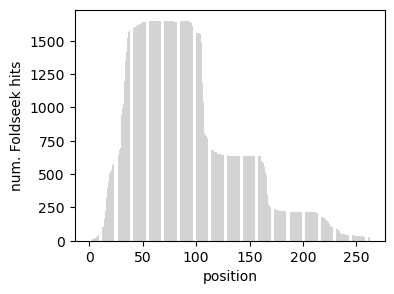

In [24]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = foldseek_search_df.copy()
figure_df = figure_df[figure_df.alignment_tm_score > 0.7].copy()
figure_df = foldseek_search_df.drop_duplicates('target_id')
# Get the indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1).astype(int)
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1)# .astype(int)

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')
plt.show()

# Most of the hits are to the N-terminal 200 residues, but the helix at the end (last 50 residues or so) is generally not matched. 

In [25]:
# Copy structures over for DALI search via the web interface. 
for output_dir_name in genes_df.index:
    path = os.path.join(ALPHAFOLD_DIR, 'af_output', output_dir_name)
    output = AlphaFoldOutput(path)
    output_path = os.path.join('/home/prichter/Downloads/', f'{output_dir_name}.pdb')
    cif_to_pdb(output.best_model_path, output_path=output_path)

In [26]:
# fig, ax = plt.subplots(figsize=(4, 4))

# figure_df = get_pairwise_alignments(genes_df.seq)
# for i in range(len(figure_df)):
#     figure_df.iloc[i, i] = 1
# figure_df = np.log(figure_df)

# sns.heatmap(figure_df, cbar=False, cmap='Blues', lw=0.7, linecolor='white')
# ax.set_ylabel('')
# ax.set_xlabel('')

# cluster_7_gene_ids.remove('orfm.bz_11.1_67')
# genes_df = pd.read_csv('../data/genes.csv', index_col=0)
# genes_df = genes_df.loc[cluster_7_gene_ids].copy()
# FASTAFile.from_df(genes_df).write('../data/genes/cluster_7.faa')

In [27]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 5

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, axes = plt.subplots(figsize=(8, 12), nrows=len(genes_df), sharex=True)

# for ax, row in zip(axes, genes_df.itertuples()):
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

#     hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

#     ax.plot(window_starts, hydrophobicity, label=row.Index, color=GENOME_ID_COLORS[row.genome_id])
#     ax.set_title(f'{row.Index} (num. TMHs: {row.num_tmhs})', fontsize='small')
#     # ax.set_ylabel('hydrophobicity')
#     ax.axhline(1, ls='--', color='black', lw=0.7)

# ax.set_xlabel('position')
# fig.tight_layout()
# plt.show()


In [28]:
# DSSP_OUTPUT_DIR = '../data/genes/dssp/'
# DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_6/'

# copy_structures(genes_df.index, source_dir='../data/genes/colabfold', output_dir=DSSP_INPUT_DIR)


# for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
#     gene_id = get_gene_id(path)
#     output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
#     if not os.path.exists(output_path):
#         subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)

# def map_dssp_to_msa(msa):
#     ids, arr = list(), list()
#     for gene_id, map_idxs in msa.get_map_idxs().items():
#         path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
#         row = np.array(list(str(DSSPFile.from_file(path))) + ['.'])
#         arr.append(row[map_idxs])
#         ids.append(id)
#     return MSA.from_array(arr, ids)

# msa = MSA.from_file('../data/genes/cluster_6.afa')
# dssp_msa = map_dssp_to_msa(msa)